# **INSTALL REQUIRED LIBRARIES**

In [1]:
!pip install transformers torch scikit-learn seaborn matplotlib pandas -q
! pip install torch
print('✅ Libraries installed!')

✅ Libraries installed!


# **Load the datasets**

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

print('✅ All libraries imported!')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Using device: {device}')

✅ All libraries imported!
 Using device: cuda


# **Loading the datasets**

In [4]:
import pandas as pd
import json

file_path = '/content/News_Category_Dataset_v3.json'
valid_records = []
corrupted_lines = 0

# Open the file and parse it line by line
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            # Try to read the line as JSON
            record = json.loads(line)
            valid_records.append(record)
        except json.JSONDecodeError:
            # If it throws an error, count it and skip to the next line
            corrupted_lines += 1

# Convert the clean data into your Pandas DataFrame
df = pd.DataFrame(valid_records)

print('✅ Dataset loaded successfully!')
print(f'Total valid rows : {len(df)}')
print(f'Corrupted lines skipped: {corrupted_lines}')
print(f'Columns          : {list(df.columns)}')
df.head()

✅ Dataset loaded successfully!
Total valid rows : 201883
Corrupted lines skipped: 1
Columns          : ['link', 'headline', 'category', 'short_description', 'authors', 'date']


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
print(f'Total unique categories: {df["category"].nunique()}\n')
print(df['category'].value_counts())

Total unique categories: 42

category
POLITICS          35602
ENTERTAINMENT     17250
WELLNESS          16348
TRAVEL             9183
STYLE & BEAUTY     8150
PARENTING          8148
HEALTHY LIVING     6694
QUEER VOICES       6248
FOOD & DRINK       6007
BUSINESS           5832
COMEDY             5263
SPORTS             5018
BLACK VOICES       4482
PARENTS            3955
HOME & LIVING      3825
THE WORLDPOST      3664
WOMEN              3572
CRIME              3529
IMPACT             3401
WORLD NEWS         3299
WEDDINGS           3274
DIVORCE            3083
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2125
TASTE              2096
TECH               1995
ARTS               1509
MONEY              1437
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
ENVIRONMENT        1323
COLLEGE            1144
LATINO VOICES      1130
CU

# **Data-processing**

In [6]:
# Check for missing values
print('Missing values:')
print(df[['headline', 'short_description', 'category']].isnull().sum())

# Drop rows where headline or category is missing
df.dropna(subset=['headline', 'category'], inplace=True)

# Fill empty short_description with empty string
df['short_description'] = df['short_description'].fillna('')

print(f'\n After cleaning: {len(df)} rows')

Missing values:
headline             0
short_description    0
category             0
dtype: int64

 After cleaning: 201883 rows


In [7]:
# Function to clean text
def clean_text(text):
    text = str(text)                              # ensure string
    text = re.sub(r'<.*?>', '', text)             # remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)   # remove special chars
    text = text.lower().strip()                   # lowercase
    return text

# Combine headline + short_description as model input
df['text'] = df['headline'] + ' ' + df['short_description']
df['text'] = df['text'].apply(clean_text)

print(' Text cleaned!')
df[['text', 'category']].head()

✅ Text cleaned!


,text,category
0,over 4 million americans roll up sleeves for o...,U.S. NEWS
1,american airlines flyer charged banned for lif...,U.S. NEWS
2,23 of the funniest tweets about cats and dogs ...,COMEDY
3,the funniest tweets from parents this week sep...,PARENTING
4,woman who called cops on black birdwatcher los...,U.S. NEWS


In [8]:
# Pick TOP 6 categories to keep training fast on Colab
# (Using all 40+ categories takes too long)
top_categories = df['category'].value_counts().head(6).index.tolist()
print('Selected categories:', top_categories)

# Keep only rows from these 6 categories
df = df[df['category'].isin(top_categories)].reset_index(drop=True)
print(f'Rows after filtering: {len(df)}')

# Encode labels as numbers  e.g. POLITICS=0, WELLNESS=1, ...
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print('\nLabel mapping:')
for i, cat in enumerate(le.classes_):
    print(f'  {i} → {cat}')

Selected categories: ['POLITICS', 'ENTERTAINMENT', 'WELLNESS', 'TRAVEL', 'STYLE & BEAUTY', 'PARENTING']
Rows after filtering: 94681

Label mapping:
  0 → ENTERTAINMENT
  1 → PARENTING
  2 → POLITICS
  3 → STYLE & BEAUTY
  4 → TRAVEL
  5 → WELLNESS


In [9]:
# Use 3000 samples so training completes quickly in Colab
df_sample = df.sample(n=3000, random_state=42).reset_index(drop=True)
print(f'✅ Using {len(df_sample)} samples')
print(df_sample['category'].value_counts())

✅ Using 3000 samples
category
POLITICS          1165
ENTERTAINMENT      555
WELLNESS           481
TRAVEL             280
STYLE & BEAUTY     268
PARENTING          251
Name: count, dtype: int64


# **Train/Validtion/test split**

In [10]:
# Split: 70% Train | 15% Validation | 15% Test
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_sample['text'], df_sample['label'],
    test_size=0.30, random_state=42,
    stratify=df_sample['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50, random_state=42,
    stratify=temp_labels
)

print(f'Train size     : {len(train_texts)}')
print(f'Validation size: {len(val_texts)}')
print(f'Test size      : {len(test_texts)}')

Train size     : 2100
Validation size: 450
Test size      : 450


# Tokenization using BERT Tokenizer

In [11]:
# Load bert-base-uncased tokenizer
# 'uncased' = treats uppercase and lowercase the same way
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
print('✅ Tokenizer loaded!')

# Quick test
sample_text = train_texts.iloc[0]
print(f'\nSample: {sample_text[:80]}...')
sample_tokens = tokenizer(sample_text, truncation=True, max_length=64)
print(f'Token IDs (first 10): {sample_tokens["input_ids"][:10]}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded!

Sample: 13 ways travelers perceive the world differently put on your travelcolored glass...
Token IDs (first 10): [101, 2410, 3971, 15183, 23084, 1996, 2088, 11543, 2404, 2006]


In [12]:
# Tokenize all three splits
# max_length=64 works well for short headlines
MAX_LEN = 64

def tokenize_data(texts):
    return tokenizer(
        list(texts),
        truncation=True,       # cut texts longer than MAX_LEN
        padding=True,          # pad shorter texts to same length
        max_length=MAX_LEN,
        return_tensors='pt'    # return as PyTorch tensors
    )

train_enc = tokenize_data(train_texts)
val_enc   = tokenize_data(val_texts)
test_enc  = tokenize_data(test_texts)

print('✅ Tokenization done!')
print(f'Train input shape: {train_enc["input_ids"].shape}')

✅ Tokenization done!
Train input shape: torch.Size([2100, 64])


# Creating Pytorch Dataset and Dataloader

In [13]:
# PyTorch Dataset class: tells PyTorch how to read our data
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return one sample at a time
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = NewsDataset(train_enc, train_labels)
val_dataset   = NewsDataset(val_enc,   val_labels)
test_dataset  = NewsDataset(test_enc,  test_labels)

# DataLoader: loads data in batches during training
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

NUM_LABELS = len(le.classes_)
print(f'✅ DataLoaders ready! Number of classes: {NUM_LABELS}')

✅ DataLoaders ready! Number of classes: 6


# Define , train and evaluate

In [14]:
def train_one_epoch(model, loader, optimizer):
    """Train model for one full pass over training data."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        optimizer.zero_grad()  # clear old gradients

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        # Forward pass through BERT
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()   # backpropagation
        optimizer.step()  # update weights

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_model(model, loader):
    """Get predictions on val/test data."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():  # no gradient needed for evaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            preds   = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels


def show_results(preds, labels, exp_name):
    """Print metrics and show confusion matrix."""
    print(f'\n{"+"*50}')
    print(f'  📊 {exp_name}')
    print(f'{"+"*50}')

    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec  = recall_score(labels, preds, average='weighted', zero_division=0)
    f1   = f1_score(labels, preds, average='weighted', zero_division=0)

    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix – {exp_name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {'Experiment': exp_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1 Score': round(f1, 4)}

print('✅ Helper functions defined!')

✅ Helper functions defined!


## **EXPERIMENT-1:FREEZE ALL BERT LAYERS**

 Experiment 1: Freeze ALL BERT layers
Only the final classification head will be trained.
--------------------------------------------------


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 4,614 / 109,486,854
  Epoch 1/3 → Loss: 1.7092 | Train Acc: 0.3090
  Epoch 2/3 → Loss: 1.6284 | Train Acc: 0.3876
  Epoch 3/3 → Loss: 1.6088 | Train Acc: 0.3871

++++++++++++++++++++++++++++++++++++++++++++++++++
  📊 Exp 1: Frozen BERT
++++++++++++++++++++++++++++++++++++++++++++++++++
  Accuracy  : 0.3867
  Precision : 0.1510
  Recall    : 0.3867
  F1 Score  : 0.2172


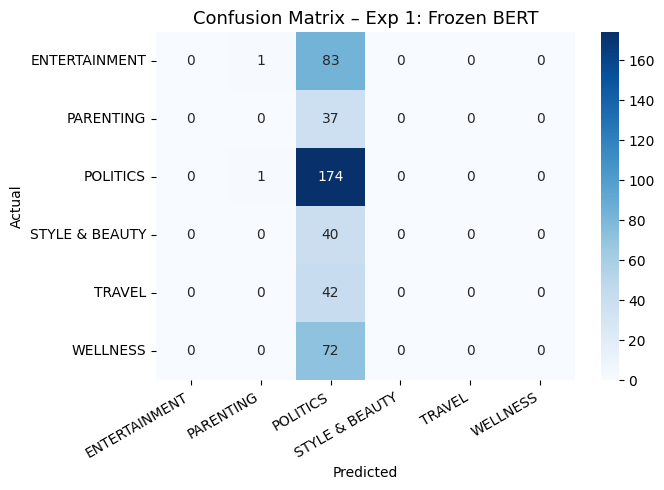

In [15]:
print(' Experiment 1: Freeze ALL BERT layers')
print('Only the final classification head will be trained.')
print('-' * 50)

# Load BERT
model1 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS
)

# Freeze ALL BERT layers
for param in model1.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model1.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

model1     = model1.to(device)
optimizer1 = AdamW(filter(lambda p: p.requires_grad, model1.parameters()), lr=2e-5)

EPOCHS = 3
for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model1, train_loader, optimizer1)
    print(f'  Epoch {epoch+1}/{EPOCHS} → Loss: {loss:.4f} | Train Acc: {acc:.4f}')

preds1, labels1 = evaluate_model(model1, test_loader)
result1 = show_results(preds1, labels1, 'Exp 1: Frozen BERT')

# EXPERIMENT 2: FINE TUNE LAST 2 BERT LAYERS

🔬 Experiment 2: Fine-tune last 2 BERT layers
Last 2 transformer layers + classifier will be trained.
--------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,180,358 / 109,486,854
  Epoch 1/3 → Loss: 1.2860 | Train Acc: 0.5662
  Epoch 2/3 → Loss: 0.6961 | Train Acc: 0.8124
  Epoch 3/3 → Loss: 0.4936 | Train Acc: 0.8743

++++++++++++++++++++++++++++++++++++++++++++++++++
  📊 Exp 2: Last 2 Layers
++++++++++++++++++++++++++++++++++++++++++++++++++
  Accuracy  : 0.8711
  Precision : 0.8761
  Recall    : 0.8711
  F1 Score  : 0.8713


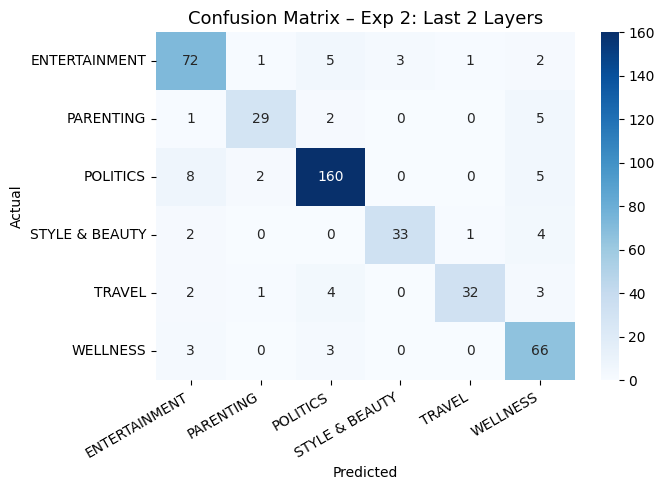

In [16]:
print('🔬 Experiment 2: Fine-tune last 2 BERT layers')
print('Last 2 transformer layers + classifier will be trained.')
print('-' * 50)

model2 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS
)

# First freeze all BERT layers
for param in model2.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer layers (index 10 and 11)
# BERT has 12 layers total (index 0 to 11)
for layer_idx in [10, 11]:
    for param in model2.bert.encoder.layer[layer_idx].parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model2.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

model2     = model2.to(device)
optimizer2 = AdamW(filter(lambda p: p.requires_grad, model2.parameters()), lr=2e-5)

for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model2, train_loader, optimizer2)
    print(f'  Epoch {epoch+1}/{EPOCHS} → Loss: {loss:.4f} | Train Acc: {acc:.4f}')

preds2, labels2 = evaluate_model(model2, test_loader)
result2 = show_results(preds2, labels2, 'Exp 2: Last 2 Layers')

# STEP-11 : EXPERIME 3 :FULL FINE TUNING (ALL LAYERS)

🔬 Experiment 3: Full Fine-Tuning (all layers trained)
--------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 109,486,854 / 109,486,854
  Epoch 1/3 → Loss: 0.9932 | Train Acc: 0.6567
  Epoch 2/3 → Loss: 0.3735 | Train Acc: 0.9071
  Epoch 3/3 → Loss: 0.1602 | Train Acc: 0.9581

++++++++++++++++++++++++++++++++++++++++++++++++++
  📊 Exp 3: Full Fine-Tuning
++++++++++++++++++++++++++++++++++++++++++++++++++
  Accuracy  : 0.8667
  Precision : 0.8735
  Recall    : 0.8667
  F1 Score  : 0.8652


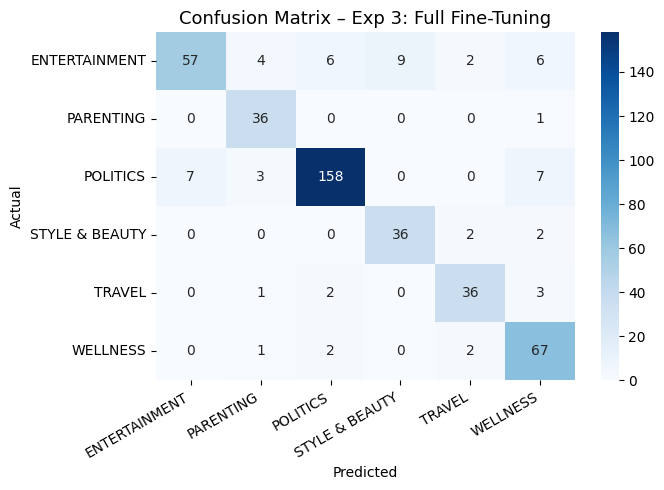

In [17]:
print('🔬 Experiment 3: Full Fine-Tuning (all layers trained)')
print('-' * 50)

# Load BERT — no freezing at all
model3 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS
)

trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model3.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

model3     = model3.to(device)
optimizer3 = AdamW(model3.parameters(), lr=2e-5)

for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model3, train_loader, optimizer3)
    print(f'  Epoch {epoch+1}/{EPOCHS} → Loss: {loss:.4f} | Train Acc: {acc:.4f}')

preds3, labels3 = evaluate_model(model3, test_loader)
result3 = show_results(preds3, labels3, 'Exp 3: Full Fine-Tuning')

# STEP-12 : COMPARE ALL 3 EXPERIMENTS

In [18]:
comparison_df = pd.DataFrame([result1, result2, result3])
print('\n Final Comparison Table:')
print(comparison_df.to_string(index=False))


📊 Final Comparison Table:
             Experiment  Accuracy  Precision  Recall  F1 Score
     Exp 1: Frozen BERT    0.3867     0.1510  0.3867    0.2172
   Exp 2: Last 2 Layers    0.8711     0.8761  0.8711    0.8713
Exp 3: Full Fine-Tuning    0.8667     0.8735  0.8667    0.8652


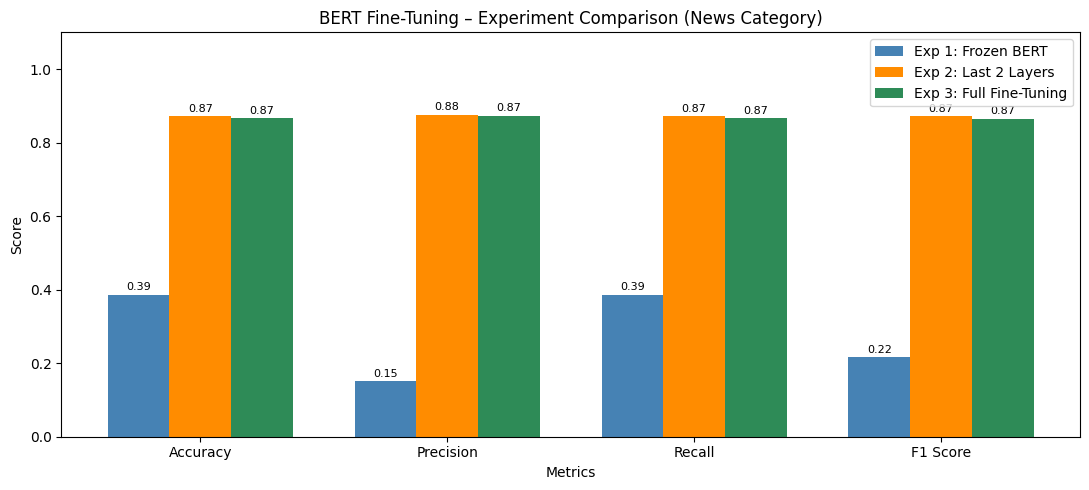

In [19]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width, [result1[m] for m in metrics], width,
            label='Exp 1: Frozen BERT',      color='steelblue')
b2 = ax.bar(x,         [result2[m] for m in metrics], width,
            label='Exp 2: Last 2 Layers',    color='darkorange')
b3 = ax.bar(x + width, [result3[m] for m in metrics], width,
            label='Exp 3: Full Fine-Tuning', color='seagreen')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('BERT Fine-Tuning – Experiment Comparison (News Category)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

🔬 Experiment 3: Full Fine-Tuning (all layers trained)
--------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 109,486,854 / 109,486,854
  Epoch 1/3 → Loss: 0.9810 | Train Acc: 0.6857
  Epoch 2/3 → Loss: 0.3177 | Train Acc: 0.9148
  Epoch 3/3 → Loss: 0.1276 | Train Acc: 0.9714

++++++++++++++++++++++++++++++++++++++++++++++++++
  📊 Exp 3: Full Fine-Tuning
++++++++++++++++++++++++++++++++++++++++++++++++++
  Accuracy  : 0.9000
  Precision : 0.9016
  Recall    : 0.9000
  F1 Score  : 0.8999


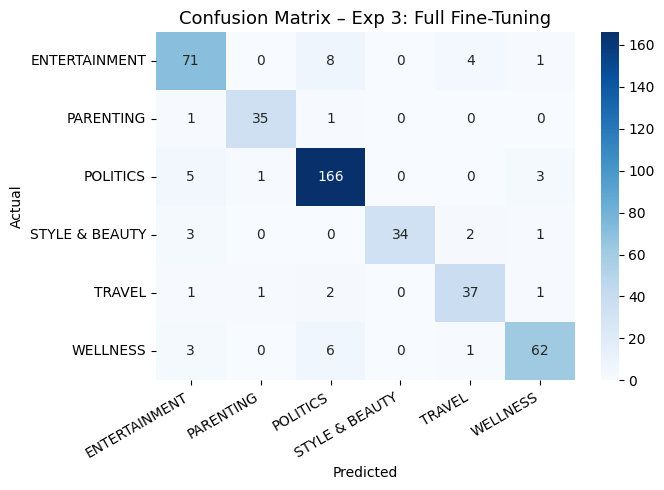

In [20]:
print('🔬 Experiment 3: Full Fine-Tuning (all layers trained)')
print('-' * 50)

# Load BERT — no freezing at all
model3 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=NUM_LABELS
)

trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model3.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

model3     = model3.to(device)
optimizer3 = AdamW(model3.parameters(), lr=2e-5)

for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model3, train_loader, optimizer3)
    print(f'  Epoch {epoch+1}/{EPOCHS} → Loss: {loss:.4f} | Train Acc: {acc:.4f}')

preds3, labels3 = evaluate_model(model3, test_loader)
result3 = show_results(preds3, labels3, 'Exp 3: Full Fine-Tuning')

# STEP-13:ANALYSIS AND INSIGHTS

In [21]:
print('''
📝 ANALYSIS & INSIGHTS
========================

Experiment 1 – Frozen BERT:
  • All BERT weights are frozen (not updated).
  • BERT acts as a fixed feature extractor.
  • Only the classifier head is trained.
  • Fastest training but lowest accuracy.
  • Good as a baseline.

Experiment 2 – Last 2 Layers Fine-tuned:
  • BERT layers 10 & 11 are unfrozen.
  • These layers learn task-specific features.
  • Better accuracy than Experiment 1.
  • Good balance of speed and performance.

Experiment 3 – Full Fine-Tuning:
  • All 12 BERT layers are trained.
  • The entire model adapts to our task.
  • Highest accuracy but slowest training.
  • Best choice when GPU time allows.

Conclusion:
  Full fine-tuning gives best results.
  If training is slow, fine-tuning the
  last 2 layers is a good trade-off.
''')


📝 ANALYSIS & INSIGHTS

Experiment 1 – Frozen BERT:
  • All BERT weights are frozen (not updated).
  • BERT acts as a fixed feature extractor.
  • Only the classifier head is trained.
  • Fastest training but lowest accuracy.
  • Good as a baseline.

Experiment 2 – Last 2 Layers Fine-tuned:
  • BERT layers 10 & 11 are unfrozen.
  • These layers learn task-specific features.
  • Better accuracy than Experiment 1.
  • Good balance of speed and performance.

Experiment 3 – Full Fine-Tuning:
  • All 12 BERT layers are trained.
  • The entire model adapts to our task.
  • Highest accuracy but slowest training.
  • Best choice when GPU time allows.

Conclusion:
  Full fine-tuning gives best results.
  If training is slow, fine-tuning the
  last 2 layers is a good trade-off.



# **STEP-14:DETAILED REPORT**

In [22]:
# Per-class breakdown for Experiment 3 (best model)
print('📋 Classification Report – Experiment 3 (Full Fine-Tuning):')
print(classification_report(labels3, preds3,
                             target_names=le.classes_,
                             zero_division=0))

📋 Classification Report – Experiment 3 (Full Fine-Tuning):
                precision    recall  f1-score   support

 ENTERTAINMENT       0.85      0.85      0.85        84
     PARENTING       0.95      0.95      0.95        37
      POLITICS       0.91      0.95      0.93       175
STYLE & BEAUTY       1.00      0.85      0.92        40
        TRAVEL       0.84      0.88      0.86        42
      WELLNESS       0.91      0.86      0.89        72

      accuracy                           0.90       450
     macro avg       0.91      0.89      0.90       450
  weighted avg       0.90      0.90      0.90       450

